In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

2026-06-20 10:31:37.073431: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781951497.292974      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781951497.359381      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781951497.887613      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781951497.887661      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781951497.887663      58 computation_placer.cc:177] computation placer alr

In [2]:


dataset_path = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"


In [3]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 24

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1781951530.846567      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781951530.852723      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [4]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", num_classes)
print(class_names[:10])

Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.GaussianNoise(0.05)
])

In [7]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=2,

    verbose=1
)

checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10


E0000 00:00:1781951550.751150      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781951594.780219     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7092 - loss: 1.1875
Epoch 1: val_accuracy improved from None to 0.90526, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 183s 71ms/step - accuracy: 0.8223 - loss: 0.7068 - val_accuracy: 0.9053 - val_loss: 0.3300 - learning_rate: 0.0010
Epoch 2/10
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9013 - loss: 0.3462
Epoch 2: val_accuracy improved from 0.90526 to 0.92837, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 144s 72ms/step - accuracy: 0.9046 - loss: 0.3259 - val_accuracy: 0.9284 - val_loss: 0.2426 - learning_rate: 0.0010
Epoch 3/10
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9166 - loss: 0.2771
Epoch 3: val_accuracy improved from 0.92837 to 0.93233, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 1

In [12]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15


E0000 00:00:1781953035.994605      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8030 - loss: 0.6666
Epoch 1: val_accuracy did not improve from 0.94605
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 180s 85ms/step - accuracy: 0.8491 - loss: 0.4980 - val_accuracy: 0.9347 - val_loss: 0.2019 - learning_rate: 1.0000e-05
Epoch 2/15
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9017 - loss: 0.3043
Epoch 2: val_accuracy improved from 0.94605 to 0.94715, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 165s 84ms/step - accuracy: 0.9081 - loss: 0.2839 - val_accuracy: 0.9472 - val_loss: 0.1607 - learning_rate: 1.0000e-05
Epoch 3/15
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9259 - loss: 0.2251
Epoch 3: val_accuracy improved from 0.94715 to 0.95341, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 165s 84ms/step - accuracy: 0.9275 - loss: 0.2194 - val_accuracy: 0.9534 - val_lo

In [15]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []             
y_pred = []

for images, labels in val_ds:

    preds = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.95      0.97       126
                                 Apple___Black_rot       1.00      0.99      1.00       132
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.97      0.99      0.98       329
                               Blueberry___healthy       0.99      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       232
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.76      0.83       108
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       219
               Corn_(maize)___Northern_Leaf_Blight       0.88      0.96      0.

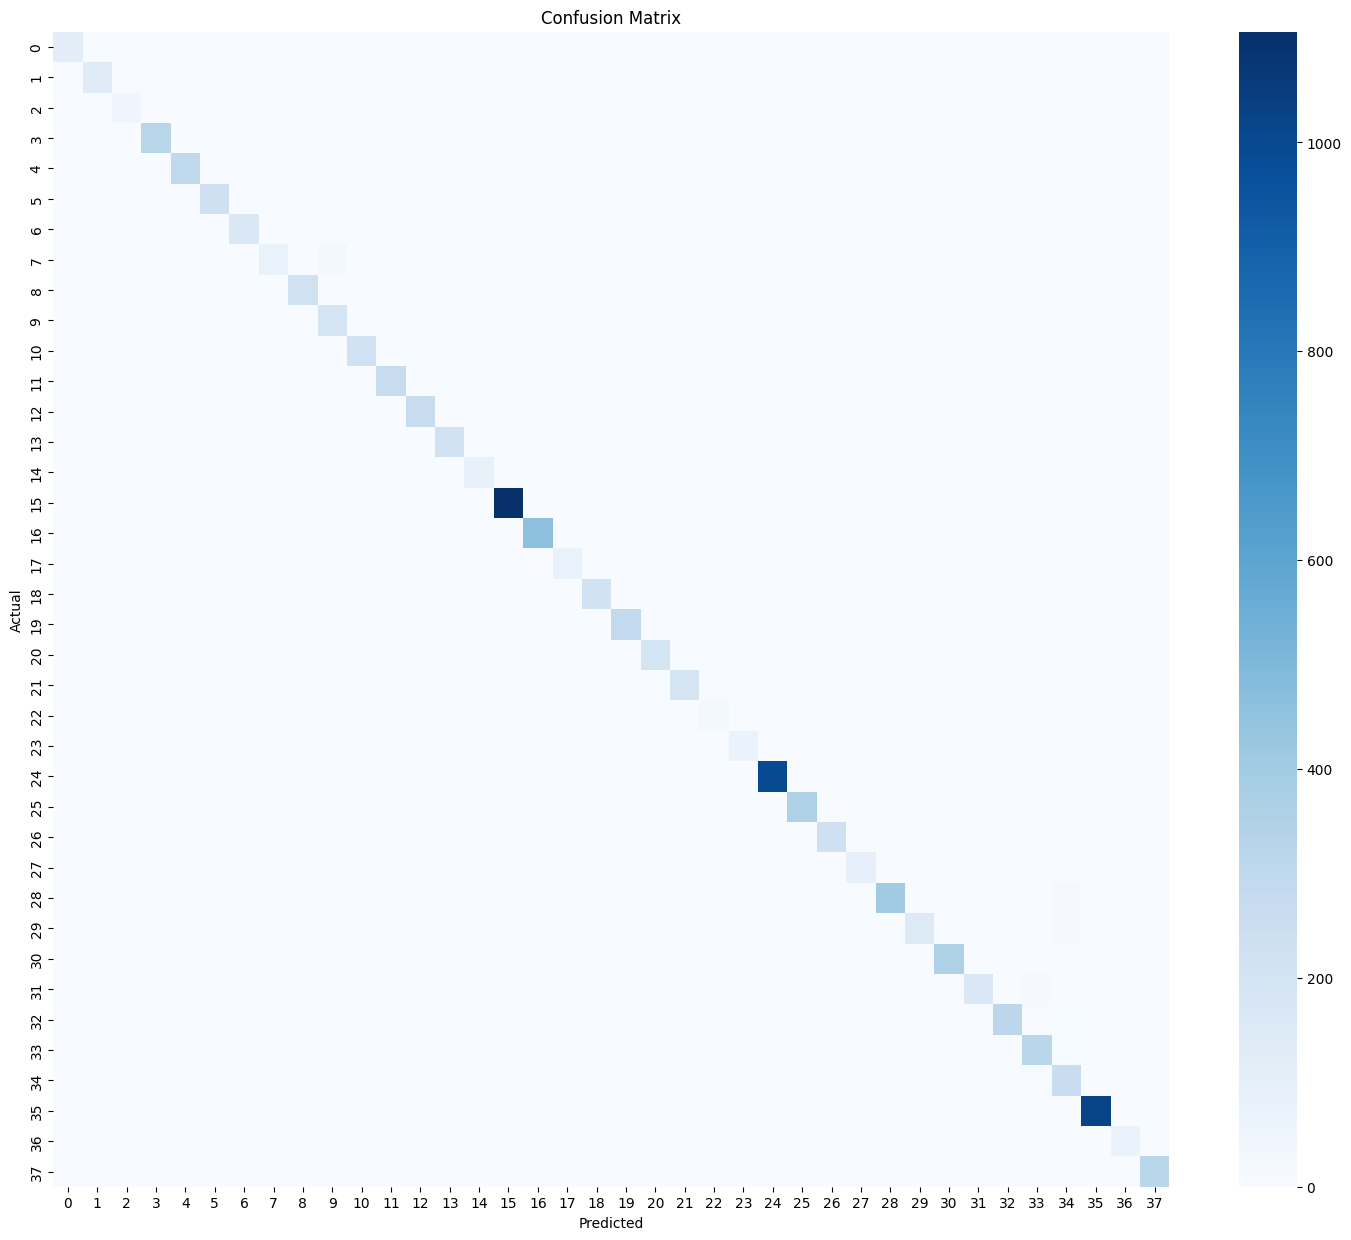

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=False
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

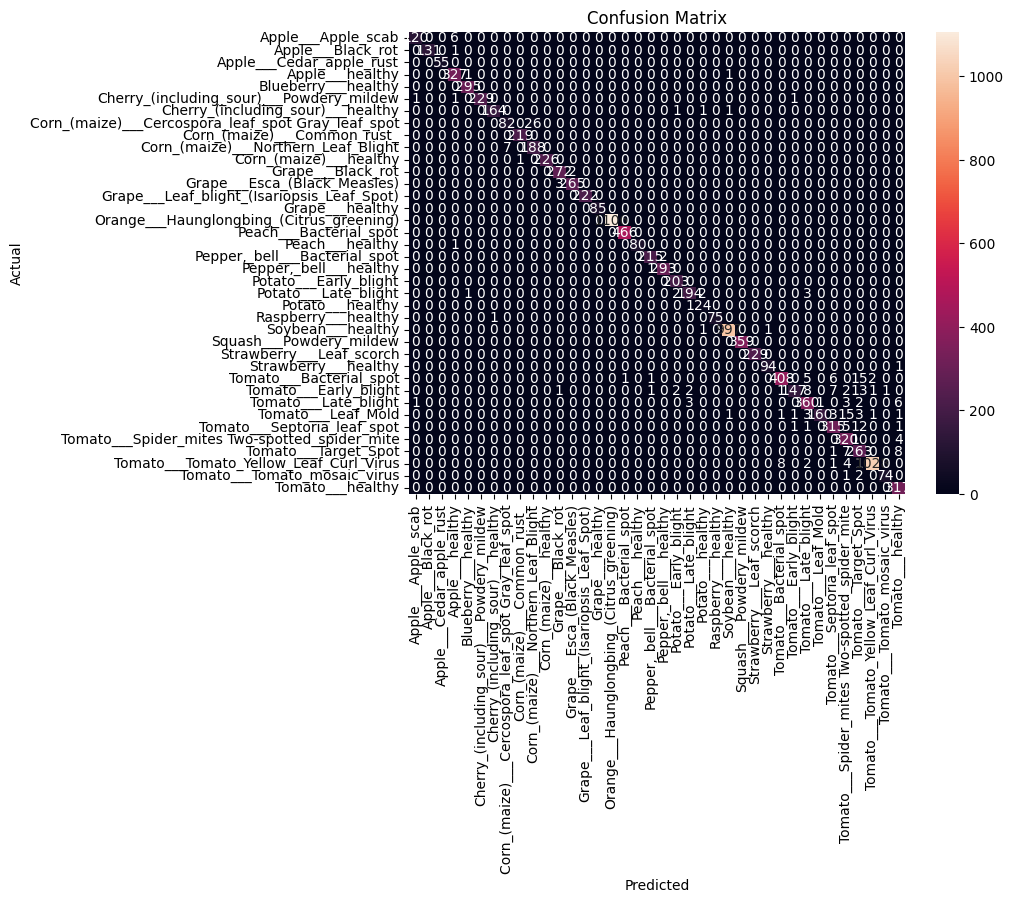

In [17]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
train_acc = (
    history.history['accuracy']
    +
    history_fine.history['accuracy']
)

val_acc = (
    history.history['val_accuracy']
    +
    history_fine.history['val_accuracy']
)

train_loss = (
    history.history['loss']
    +
    history_fine.history['loss']
)

val_loss = (
    history.history['val_loss']
    +
    history_fine.history['val_loss']
)

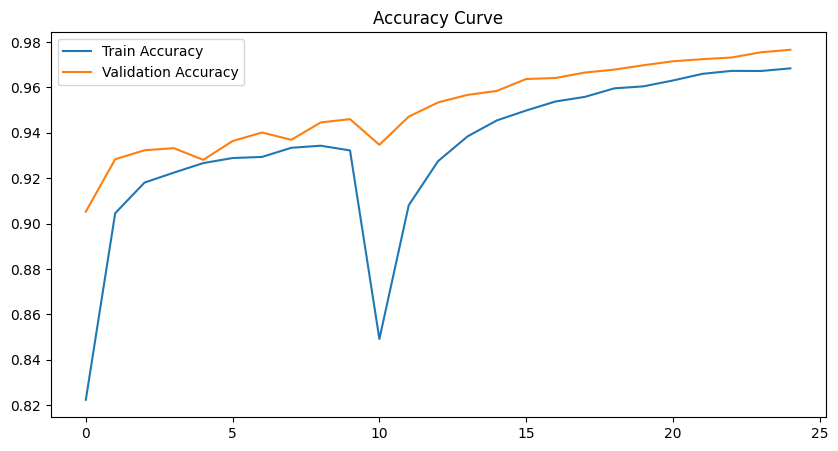

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    train_acc,
    label='Train Accuracy'
)

plt.plot(
    val_acc,
    label='Validation Accuracy'
)

plt.legend()

plt.title("Accuracy Curve")

plt.show()

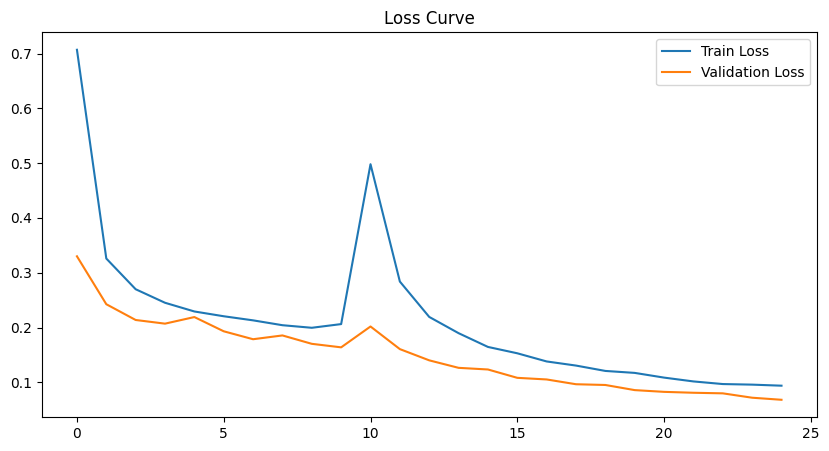

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    train_loss,
    label='Train Loss'
)

plt.plot(
    val_loss,
    label='Validation Loss'
)

plt.legend()

plt.title("Loss Curve")

plt.show()

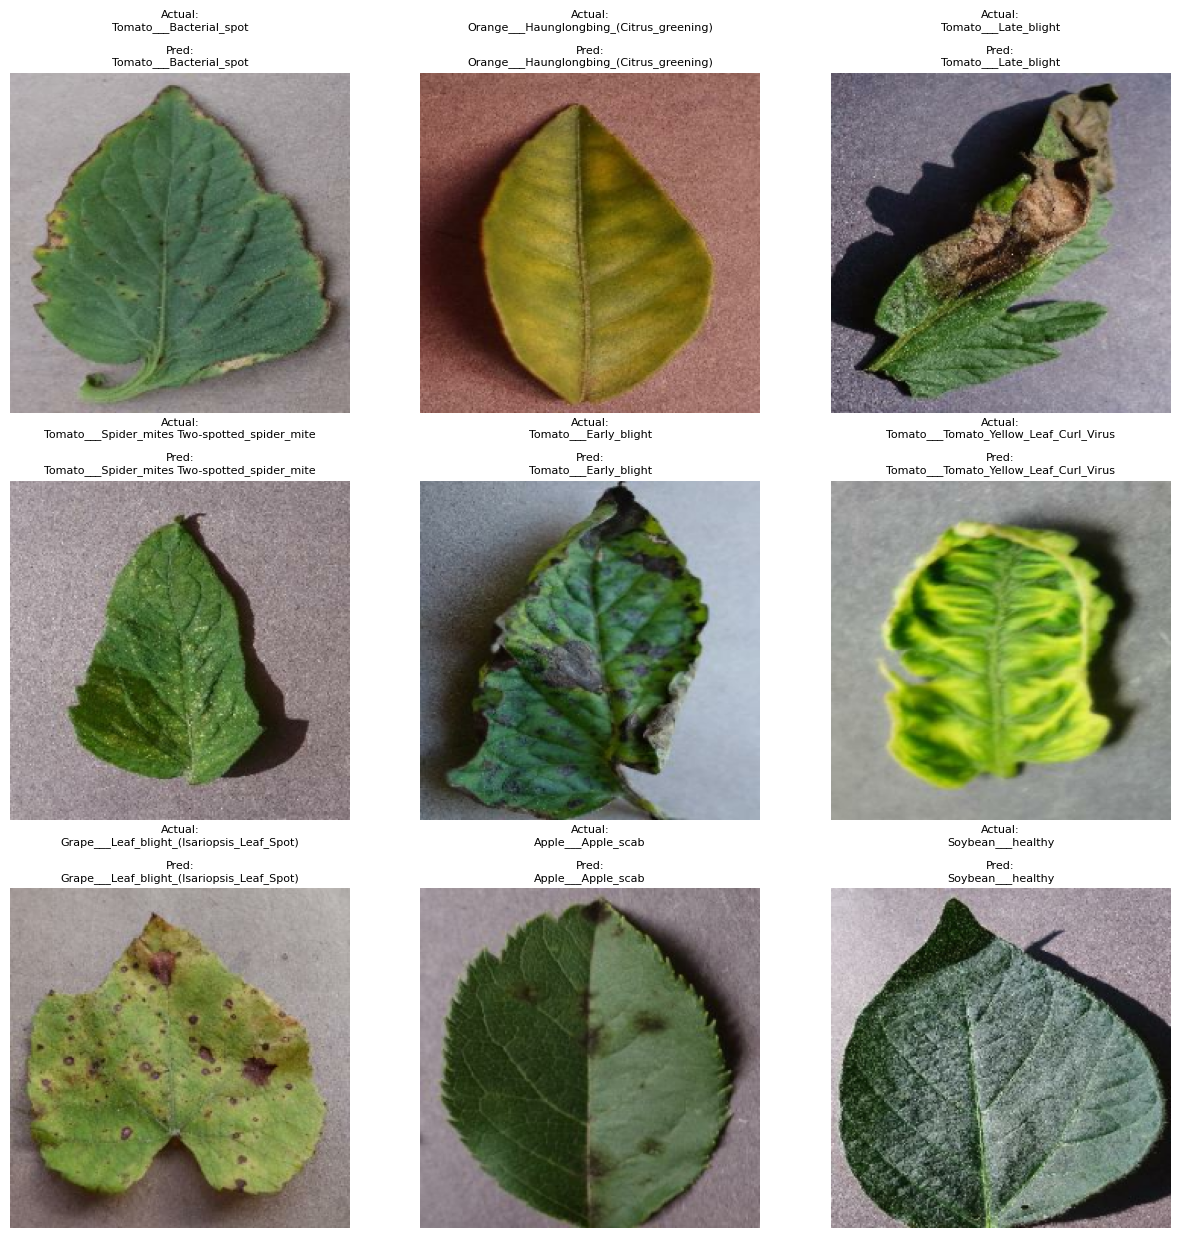

In [21]:
import matplotlib.pyplot as plt

for images, labels in val_ds.take(1):

    preds = model.predict(
        images,
        verbose=0
    )

    pred_labels = np.argmax(
        preds,
        axis=1
    )

    plt.figure(figsize=(15,15))

    for i in range(9):

        ax = plt.subplot(
            3,
            3,
            i+1
        )

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[
            labels[i]
        ]

        predicted = class_names[
            pred_labels[i]
        ]

        plt.title(
            f"Actual:\n{actual}\n\nPred:\n{predicted}",
            fontsize=8
        )

        plt.axis("off")

    plt.show()

In [22]:
loss, accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.9766 - loss: 0.0682
Validation Loss: 0.0682
Validation Accuracy: 0.9766


In [24]:
import json

# Save model
model.save("/kaggle/working/EffecientNetB0.keras")

# Save class names
with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)